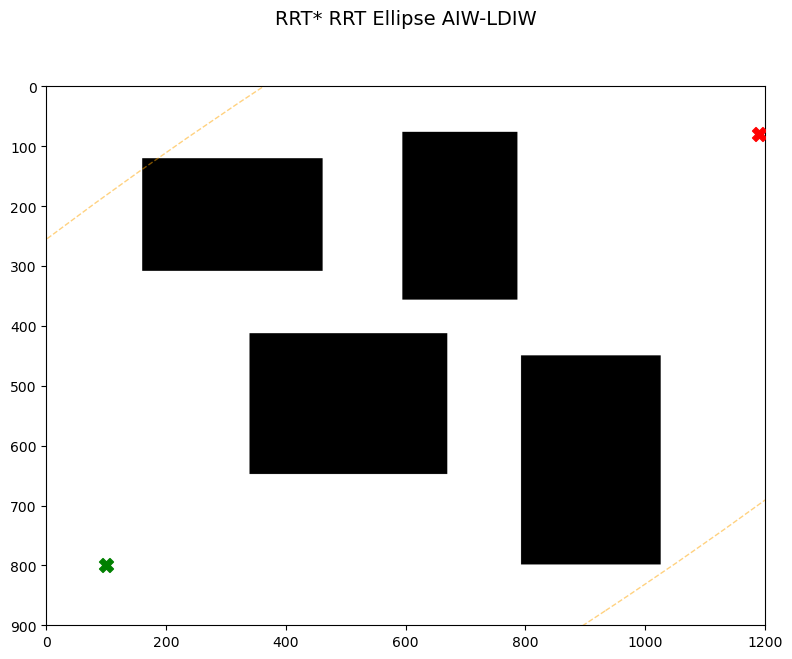

Path found! 
Iterations: 207 
Final Goal Bias: 0.38 
Succes Rate: 63.3 % 


In [2]:
import math
import random
import numpy as np

from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

img = Image.open('./images/mapa3.png')
img = ImageOps.grayscale(img)
img = ImageOps.invert(img)

np_img = np.array(img)
np_img = (np_img > 128).astype(np.uint8)

class treeNode():
    def __init__(self, locationX, locationY):
        self.locationX = locationX
        self.locationY = locationY
        self.children = []
        self.parent = None
        self.cost = 0.0

class Tree():
    def __init__(self, start_node):
        self.nodes = [start_node]


    def add_node(self, new_node, parent_node):
        self.nodes.append(new_node)
        parent_node.children.append(new_node)
        new_node.parent = parent_node
        return

    def nearest(self,new_node):
        best = None
        min_dist = float('inf')
        for node in self.nodes:
            dist = math.dist((node.locationX, node.locationY),(new_node.locationX, new_node.locationY))
            if dist < min_dist:
                min_dist = dist
                best = node

        return best

    def path_recovery(self,final_node):
        path = []

        while final_node.parent is not None:
            path.append(final_node)
            final_node = final_node.parent
        #path.reverse()
        return path

    def distance(self,node1,node2):
        return math.dist((node1.locationX,node1.locationY), (node2.locationX,node2.locationY))
    
    def near(self, node_mid, radius):
        nodes_list= []

        for node in self.nodes:
            if self.distance(node_mid, node) <= radius:
                nodes_list.append(node)

        return nodes_list
    
    def rewire(self, child, new_parent):

        if child.parent:
            child.parent.children.remove(child)
        child.parent = new_parent
        new_parent.children.append(child)
        
        return
    
    def update_descendant_costs(self, node):
        if node.parent:
            new_cost = node.parent.cost + self.distance(node.parent, node)
            
            if abs(node.cost - new_cost) > 1e-6:
                node.cost = new_cost
                
                for child in node.children:
                    self.update_descendant_costs(child)
        
        return


def collision_free(p1,p2,mapa):
    x1, y1 = p1.locationX, p1.locationY
    x2, y2 = p2.locationX, p2.locationY

    h, w = mapa.shape
    if not (0 <= x1 < w and 0 <= y1 < h and 0 <= x2 < w and 0 <= y2 < h):
        return False

    num_points = int(max(abs(x1-x2), abs(y1-y2)))

    if num_points == 0:
        return True

    for i in range(num_points + 1):
        t = i / max(num_points, 1)
        x = round(x1 + (x2 - x1) * t)
        y = round(y1 + (y2 - y1) * t)
        if mapa[y, x]  == 1:
            return False
    return True

def get_ellipse_params(start, goal, par_1=1.5, par_2=0.4):
    d = math.dist(start, goal)
    a = par_1 * d
    b = par_2 * d
    sr_x = (start[0] + goal[0]) / 2
    sr_y = (start[1] + goal[1]) / 2
    theta = math.atan2(goal[1] - start[1], goal[0] - start[0])
    return sr_x, sr_y, a, b, theta

def samp_point_elipse(start, goal, mapa, par_1 = 1.5, par_2 = 0.4):

    while True:
        d = math.dist(start,goal)
        a = par_1 * d
        b = par_2 * d
        sr_x = (start[0] + goal[0])  / 2
        sr_y = (start[1] + goal[1])  / 2
        theta = math.atan2(goal[1] - start[1], goal[0] - start[0])

        phi = random.uniform(0, 2 * math.pi)
        r = math.sqrt(random.uniform(0, 1))
        x_norm= a * r * math.cos(phi)
        y_norm = b * r * math.sin(phi)

        X = x_norm * math.cos(theta) - y_norm * math.sin(theta) + sr_x
        Y = x_norm * math.sin(theta) + y_norm * math.cos(theta) + sr_y

        if 0 <= X < mapa.shape[1] and 0 <= Y < mapa.shape[0]:
            if mapa[int(Y), int(X)] == 0:
                return treeNode(X, Y)

# Warianty funkcji

# def rrt_ellipse(start, goal, mapa, step_len = 40, max_iter = 1000, tolerance = 3 ,goal_bias = 0.1):


    
#     plt.ion()
#     h, w = mapa.shape
    
#     fig, ax = plt.subplots(figsize=(12, 7)) 

#     ax.set_xlim(0, w)
#     ax.set_ylim(h, 0)
#     ax.imshow(mapa, cmap='binary')
#     ax.set_title("rrt_elipse", y=1.05, fontsize=14)
    

#     ax.scatter(start[0], start[1], c='red', s=100, marker='X', zorder=5)
#     ax.scatter(goal[0], goal[1], c='green', s=100, marker='X', zorder=5)

#     start_node = treeNode(start[0], start[1])
#     tree = Tree(start_node)
#     sr_x, sr_y, a, b, theta = get_ellipse_params(start, goal)
#     ellipse_patch = patches.Ellipse((sr_x, sr_y), width=2*a, height=2*b, angle=math.degrees(theta), 
#                                     fill=False, color='orange', linestyle='--', alpha=0.5, linewidth=1)
#     ax.add_patch(ellipse_patch)
#     iter_text = ax.text(0, 1.02, '', transform=ax.transAxes, fontsize=8, color='blue', fontweight='bold')


#     plt.pause(1)

#     for i in range(max_iter):

#         iter_text.set_text(f'Iteracja: {i}')

#         if random.random() < goal_bias:
#             sample_node = treeNode(goal[0], goal[1])

#         else:
#             sample_node = samp_point_elipse(start,goal, mapa)

#         pt, = ax.plot(sample_node.locationX, sample_node.locationY, marker='o', color='red', markersize=15)

#         pot_parent = tree.nearest(sample_node)
#         distance = tree.distance(pot_parent,sample_node)

#         if distance <= step_len:
#             new_node = sample_node
#         else:

#             stepX = ((sample_node.locationX - pot_parent.locationX) / distance) * step_len
#             stepY = ((sample_node.locationY - pot_parent.locationY) / distance) * step_len
#             new_node = treeNode(pot_parent.locationX + stepX, pot_parent.locationY + stepY)

#         if collision_free(pot_parent,new_node,mapa):
#             tree.add_node(new_node,pot_parent)
#             ax.plot([pot_parent.locationX, new_node.locationX], [pot_parent.locationY, new_node.locationY], c='blue', linewidth=2)


#             if tree.distance(new_node, treeNode(goal[0], goal[1])) < tolerance:
#                 tree.add_node(treeNode(goal[0], goal[1]), new_node)
#                 found_path = tree.path_recovery(tree.nodes[-1])
#                 for node in found_path:
#                     if node.parent is None:
#                         pass
#                     else:
#                         ax.plot([node.locationX, node.parent.locationX], [node.locationY, node.parent.locationY],
#                                 c='green', linewidth=4)
#                         #plt.pause(0.03)

#                 plt.ioff()
#                 plt.show()

#                 return f"Path found in {i} iterations", i


#         #plt.pause(0.001)
#         try:
#             pt.remove()
#         except:
#             pass
#     return "Path not found"

# def rrt_ellipse_aiw(start, goal, mapa, step_len = 40, max_iter = 1000, tolerance = 3 , pmax = 0.4 , pmin = 0.05):

    
#     plt.ion()
#     h, w = mapa.shape
    
#     fig, ax = plt.subplots(figsize=(12, 7)) 

#     ax.set_xlim(0, w)
#     ax.set_ylim(h, 0)
#     ax.imshow(mapa, cmap='binary')
#     ax.set_title("rrt_elipse_aiw", y=1.05, fontsize=14)
    

#     ax.scatter(start[0], start[1], c='red', s=100, marker='X', zorder=5)
#     ax.scatter(goal[0], goal[1], c='green', s=100, marker='X', zorder=5)

#     start_node = treeNode(start[0], start[1])
#     tree = Tree(start_node)

#     sr_x, sr_y, a, b, theta = get_ellipse_params(start, goal)
#     ellipse_patch = patches.Ellipse((sr_x, sr_y), width=2*a, height=2*b, angle=math.degrees(theta), 
#                                     fill=False, color='orange', linestyle='--', alpha=0.5, linewidth=1)
#     ax.add_patch(ellipse_patch)

#     iter_text = ax.text(0, 1.02, '', transform=ax.transAxes, fontsize=8, color='blue', fontweight='bold')
#     weight_text = ax.text(0.2, 1.02, '', transform=ax.transAxes, fontsize=8, color='blue', fontweight='bold')
#     succes_rate_text = ax.text(0.4, 1.02, '', transform=ax.transAxes, fontsize=8, color='blue', fontweight='bold')

#     plt.pause(1)
#     success = 0
#     ps = 0.0
#     pa = pmin
    
#     for i in range(1,max_iter + 1):

#         ps = success / i

#         pa = pmin + (pmax - pmin) * ps
#         pa = np.clip(pa, pmin, pmax)

#         if i % 5 == 0:
#             iter_text.set_text(f'Iteracja: {i}') 
#             weight_text.set_text(f'Goal Bias: {pa:.2f}')
#             succes_rate_text.set_text(f'Success Rate: {ps:.3f}')


#         if random.random() < pa:
#             sample_node = treeNode(goal[0], goal[1])


#         else:
#             sample_node = samp_point_elipse(start,goal, mapa)

#         pt, = ax.plot(sample_node.locationX, sample_node.locationY, marker='o', color='red', markersize=15)

#         pot_parent = tree.nearest(sample_node)
#         distance = tree.distance(pot_parent,sample_node)

#         if distance <= step_len:
#             new_node = sample_node
            

#         else:
#             stepX = ((sample_node.locationX - pot_parent.locationX) / distance) * step_len
#             stepY = ((sample_node.locationY - pot_parent.locationY) / distance) * step_len
#             new_node = treeNode(pot_parent.locationX + stepX, pot_parent.locationY + stepY)

#         if collision_free(pot_parent,new_node,mapa):
#             tree.add_node(new_node,pot_parent)
#             success += 1
#             ax.plot([pot_parent.locationX, new_node.locationX], [pot_parent.locationY, new_node.locationY], c='blue', linewidth=2)


#             if tree.distance(new_node, treeNode(goal[0], goal[1])) < tolerance:
#                 tree.add_node(treeNode(goal[0], goal[1]), new_node)
#                 found_path = tree.path_recovery(tree.nodes[-1])
#                 for node in found_path:
#                     if node.parent is None:
#                         pass
#                     else:
#                         ax.plot([node.locationX, node.parent.locationX], [node.locationY, node.parent.locationY],
#                                 c='green', linewidth=4)
#                         #plt.pause(0.03)

#                 plt.ioff()
#                 plt.show()

#                 return f"Path found! \nIterations: {i} \nFinal Goal Bias: {pa:.2f} \nSucces Rate: {100 * ps:.1f} % "

#         #plt.pause(0.001)
#         try:
#             pt.remove()
#         except:
#             pass

#     return "Path not found"

# def rrt_ellipse_aiw_ldiw(start, goal, mapa, step_len = 40, max_iter = 1000, tolerance = 3 , pmax = 0.4 , pmin = 0.05):

#     plt.ion()
#     h, w = mapa.shape
    
#     fig, ax = plt.subplots(figsize=(12, 7)) 

#     ax.set_xlim(0, w)
#     ax.set_ylim(h, 0)
#     ax.imshow(mapa, cmap='binary')
#     ax.set_title("rrt_elipse_aiw_ldiw", y=1.05, fontsize=14)
    

#     ax.scatter(start[0], start[1], c='red', s=100, marker='X', zorder=5)
#     ax.scatter(goal[0], goal[1], c='green', s=100, marker='X', zorder=5)

#     start_node = treeNode(start[0], start[1])
#     tree = Tree(start_node)

#     sr_x, sr_y, a, b, theta = get_ellipse_params(start, goal)
#     ellipse_patch = patches.Ellipse((sr_x, sr_y), width=2*a, height=2*b, angle=math.degrees(theta), 
#                                     fill=False, color='orange', linestyle='--', alpha=0.5, linewidth=1)
#     ax.add_patch(ellipse_patch)

#     iter_text = ax.text(0, 1.02, '', transform=ax.transAxes, fontsize=8, color='blue', fontweight='bold')
#     weight_text = ax.text(0.2, 1.02, '', transform=ax.transAxes, fontsize=8, color='blue', fontweight='bold')
#     succes_rate_text = ax.text(0.4, 1.02, '', transform=ax.transAxes, fontsize=8, color='blue', fontweight='bold')

#     plt.pause(1)
#     success = 0
#     ps = 0.0
#     pa = pmin
    
#     for i in range(1,max_iter + 1):

#         ps = success / i

#         if ps < 1e-6:
#             ps = 1e-6
        
#         time_factor = (max_iter-i) / max_iter   
#         term_1 = (pmax-pmin) / ps
#         term_2 = (pmax-(pmax-pmin)) / ps
#         pa = 1 - (term_1 + time_factor*term_2)
#         pa = np.clip(pa, pmin, pmax)

#         if i % 5 == 0:
#             iter_text.set_text(f'Iteracja: {i}') 
#             weight_text.set_text(f'Goal Bias: {pa:.2f}')
#             succes_rate_text.set_text(f"Succes Rate: {100 * ps:.1f} %")


#         if random.random() < pa:
#             sample_node = treeNode(goal[0], goal[1])


#         else:
#             sample_node = samp_point_elipse(start,goal,mapa)

#         pt, = ax.plot(sample_node.locationX, sample_node.locationY, marker='o', color='red', markersize=15)

#         pot_parent = tree.nearest(sample_node)
#         distance = tree.distance(pot_parent,sample_node)

#         if distance <= step_len:
#             new_node = sample_node
            

#         else:
#             stepX = ((sample_node.locationX - pot_parent.locationX) / distance) * step_len
#             stepY = ((sample_node.locationY - pot_parent.locationY) / distance) * step_len
#             new_node = treeNode(pot_parent.locationX + stepX, pot_parent.locationY + stepY)

#         if collision_free(pot_parent,new_node,mapa):
#             tree.add_node(new_node,pot_parent)
#             success += 1
#             ax.plot([pot_parent.locationX, new_node.locationX], [pot_parent.locationY, new_node.locationY], c='blue', linewidth=2)


#             if tree.distance(new_node, treeNode(goal[0], goal[1])) < tolerance:
#                 tree.add_node(treeNode(goal[0], goal[1]), new_node)
#                 found_path = tree.path_recovery(tree.nodes[-1])
#                 for node in found_path:
#                     if node.parent is None:
#                         pass
#                     else:
#                         ax.plot([node.locationX, node.parent.locationX], [node.locationY, node.parent.locationY],
#                                 c='green', linewidth=4)
#                         #plt.pause(0.03)

#                 plt.ioff()
#                 plt.show()

#                 return f"Path found! \nIterations: {i} \nFinal Goal Bias: {pa:.2f} \nSucces Rate: {100 * ps:.1f} % "

#         #plt.pause(0.001)
#         try:
#             pt.remove()
#         except:
#             pass

#     return "Path not found"

# def rrt_ellipse_aiw_ldiw_star(start, goal, mapa, step_len = 40, max_iter = 1000, tolerance = 3 , pmax = 0.4 , pmin = 0.05):

#     RRT_STAR_RADIUS = 5 * step_len
#     plt.ion()
#     h, w = mapa.shape
    
#     fig, ax = plt.subplots(figsize=(12, 7)) 

#     ax.set_xlim(0, w)
#     ax.set_ylim(h, 0)
#     ax.imshow(mapa, cmap='binary')
#     ax.set_title("rrt_elipse_aiw_ldiw", y=1.05, fontsize=14)
    

#     ax.scatter(start[0], start[1], c='red', s=100, marker='X', zorder=5)
#     ax.scatter(goal[0], goal[1], c='green', s=100, marker='X', zorder=5)

#     start_node = treeNode(start[0], start[1])
#     tree = Tree(start_node)

#     sr_x, sr_y, a, b, theta = get_ellipse_params(start, goal)
#     ellipse_patch = patches.Ellipse((sr_x, sr_y), width=2*a, height=2*b, angle=math.degrees(theta), 
#                                     fill=False, color='orange', linestyle='--', alpha=0.5, linewidth=1)
#     ax.add_patch(ellipse_patch)

#     iter_text = ax.text(0, 1.02, '', transform=ax.transAxes, fontsize=8, color='blue', fontweight='bold')
#     weight_text = ax.text(0.2, 1.02, '', transform=ax.transAxes, fontsize=8, color='blue', fontweight='bold')
#     succes_rate_text = ax.text(0.4, 1.02, '', transform=ax.transAxes, fontsize=8, color='blue', fontweight='bold')

#     plt.pause(1)
#     success = 0
#     ps = 0.0
#     pa = pmin
    
#     for i in range(1,max_iter + 1):

#         ps = success / i

#         if ps < 1e-6:
#             ps = 1e-6
        
#         time_factor = (max_iter-i) / max_iter   
#         term_1 = (pmax-pmin) / ps
#         term_2 = (pmax-(pmax-pmin)) / ps
#         pa = 1 - (term_1 + time_factor*term_2)
#         pa = np.clip(pa, pmin, pmax)

#         if i % 5 == 0:
#             iter_text.set_text(f'Iteracja: {i}') 
#             weight_text.set_text(f'Goal Bias: {pa:.2f}')
#             succes_rate_text.set_text(f"Succes Rate: {100 * ps:.1f} %")


#         if random.random() < pa:
#             sample_node = treeNode(goal[0], goal[1])
#         else:
#             sample_node = samp_point_elipse(start,goal,mapa)

#         #pt, = ax.plot(sample_node.locationX, sample_node.locationY, marker='o', color='red', markersize=15)

#         pot_parent = tree.nearest(sample_node)
#         distance = tree.distance(pot_parent,sample_node)

#         if distance <= step_len:
#             new_node = sample_node
            

#         else:
#             stepX = ((sample_node.locationX - pot_parent.locationX) / distance) * step_len
#             stepY = ((sample_node.locationY - pot_parent.locationY) / distance) * step_len
#             new_node = treeNode(pot_parent.locationX + stepX, pot_parent.locationY + stepY)

#         near_nodes = tree.near(new_node, RRT_STAR_RADIUS)
#         best_parent = pot_parent

#         if pot_parent:
#             min_cost = pot_parent.cost + tree.distance(pot_parent, new_node)
#         else:
#             min_cost = float('inf')
#         for near_node in near_nodes:
#             new_path_cost = near_node.cost + tree.distance(near_node, new_node)

#             if new_path_cost < min_cost and collision_free(near_node, new_node, mapa):
#                 min_cost = new_path_cost
#                 best_parent = near_node

#         new_node.cost = min_cost
#         pot_parent = best_parent

#         if pot_parent and collision_free(pot_parent, new_node, mapa):
#             tree.add_node(new_node, pot_parent)
#             success += 1
#             ax.plot([pot_parent.locationX, new_node.locationX], [pot_parent.locationY, new_node.locationY], c='blue', linewidth=1)

#             for near_node in near_nodes:
#                 rewire_cost = new_node.cost + tree.distance(new_node, near_node)
                
#                 if rewire_cost < near_node.cost and collision_free(new_node, near_node, mapa):
                    
#                     tree.rewire(near_node, new_node)
#                     near_node.cost = rewire_cost
#                     tree.update_descendant_costs(near_node)


#             if tree.distance(new_node, treeNode(goal[0], goal[1])) < tolerance:
#                 tree.add_node(treeNode(goal[0], goal[1]), new_node)
#                 found_path = tree.path_recovery(tree.nodes[-1])
#                 for node in found_path:
#                     if node.parent is None:
#                         pass
#                     else:
#                         ax.plot([node.locationX, node.parent.locationX], [node.locationY, node.parent.locationY],
#                                 c='green', linewidth=4)
#                         #plt.pause(0.03)

#                 plt.ioff()
#                 plt.show()

#                 return f"Path found! \nIterations: {i} \nFinal Goal Bias: {pa:.2f} \nSucces Rate: {100 * ps:.1f} % "

#         #plt.pause(0.001)
#         try:
#             pt.remove()
#         except:
#             pass

#     return "Path not found"

# Funkcja łącząca warianty bias_mode = { 'FIXED' , 'AIW' , 'HYBRID'}
def rrt_solver(start, goal, mapa, step_len = 25, max_iter=1000, tolerance=30, bias_mode='FIXED', is_rrt_star=False, fixed_bias=0.9, pmax=0.4, pmin=0.05):
    plt.ion()
    h, w = mapa.shape
    
    fig, ax = plt.subplots(figsize=(12, 7)) 
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.imshow(mapa, cmap='binary')

    if bias_mode == 'FIXED':
        title = f"RRT Ellipse (Bias={fixed_bias:.2f})"
    elif bias_mode == 'AIW':
        title = "RRT Ellipse AIW"
    elif bias_mode == 'HYBRID':
        title = "RRT Ellipse AIW-LDIW"
    else:
        title = "RRT Solver (Unknown Mode)"
    
    if is_rrt_star:
         title = "RRT* " + title
    
    ax.set_title(title, y=1.1, fontsize=14)
    
    ax.scatter(start[0], start[1], c='red', s=100, marker='X', zorder=5)
    ax.scatter(goal[0], goal[1], c='green', s=100, marker='X', zorder=5)

    start_node = treeNode(start[0], start[1])
    tree = Tree(start_node)

    sr_x, sr_y, a, b, theta = get_ellipse_params(start, goal)
    ellipse_patch = patches.Ellipse((sr_x, sr_y), width=2*a, height=2*b, angle=math.degrees(theta), 
                                    fill=False, color='orange', linestyle='--', alpha=0.5, linewidth=1)
    ax.add_patch(ellipse_patch)

    iter_text = ax.text(0, 1.01, '', transform=ax.transAxes, fontsize=10, color='blue', fontweight='bold')
    weight_text = ax.text(0.25, 1.01, '', transform=ax.transAxes, fontsize=10, color='blue', fontweight='bold')
    succes_rate_text = ax.text(0.5, 1.01, '', transform=ax.transAxes, fontsize=10, color='blue', fontweight='bold')

    plt.pause(0.5)
    
    RRT_STAR_RADIUS = 5 * step_len
    success = 0
    pa = pmin

    for i in range(1, max_iter + 1):
        if bias_mode != 'FIXED':
            ps = success / i
            if ps < 1e-6:
                ps = 1e-6

            if bias_mode == 'AIW':
                pa = pmin + (pmax - pmin) * ps
            elif bias_mode == 'HYBRID':
                time_factor = (max_iter - i) / max_iter 
                term_1 = (pmax - pmin) / ps
                term_2 = pmin / ps
                pa = 1 - (term_1 + time_factor * term_2)
            pa = np.clip(pa, pmin, pmax)
        else: 
            pa = fixed_bias
            ps = success / i

        if i % 5 == 0:
            iter_text.set_text(f'Iteracja: {i}') 
            weight_text.set_text(f'Goal Bias: {pa:.2f}')
            succes_rate_text.set_text(f"Success Rate: {100 * ps:.1f}%")

        if random.random() < pa:
            sample_node = treeNode(goal[0], goal[1])
        else:
            sample_node = samp_point_elipse(start, goal, mapa)

        pot_parent = tree.nearest(sample_node)
        distance = tree.distance(pot_parent, sample_node)

        if distance <= step_len:
            new_node = sample_node
        else:
            stepX = ((sample_node.locationX - pot_parent.locationX) / distance) * step_len
            stepY = ((sample_node.locationY - pot_parent.locationY) / distance) * step_len
            new_node = treeNode(pot_parent.locationX + stepX, pot_parent.locationY + stepY)

        final_parent = pot_parent
        new_cost = 0.0
        if pot_parent:
            new_cost = pot_parent.cost + tree.distance(pot_parent, new_node)

        if is_rrt_star:
            near_nodes = tree.near(new_node, RRT_STAR_RADIUS)
            min_cost = new_cost
            best_parent = final_parent

            for near_node in near_nodes:
                potential_cost = near_node.cost + tree.distance(near_node, new_node)
                if potential_cost < min_cost and collision_free(near_node, new_node, mapa):
                    min_cost = potential_cost
                    best_parent = near_node
            
            final_parent = best_parent
            new_cost = min_cost
        
        new_node.cost = new_cost

        if final_parent and collision_free(final_parent, new_node, mapa):
            tree.add_node(new_node, final_parent)
            success += 1
            ax.plot([final_parent.locationX, new_node.locationX], [final_parent.locationY, new_node.locationY], c='blue', linewidth=1)

            if is_rrt_star:
                for near_node in near_nodes:
                    rewire_cost = new_node.cost + tree.distance(new_node, near_node)
                    if rewire_cost < near_node.cost and collision_free(new_node, near_node, mapa):
                        tree.rewire(near_node, new_node)
                        tree.update_descendant_costs(near_node)

            if tree.distance(new_node, treeNode(goal[0], goal[1])) < tolerance:
                tree.add_node(treeNode(goal[0], goal[1]), new_node)
                found_path = tree.path_recovery(tree.nodes[-1])
                for node in found_path:
                    if node.parent is None:
                        pass
                    else:
                        ax.plot([node.locationX, node.parent.locationX], [node.locationY, node.parent.locationY], c='green', linewidth=4)
                        #plt.pause(0.03)

                plt.ioff()
                plt.show()

                if bias_mode == 'FIXED':
                    return f"Path found! \nIterations: {i}"
                return f"Path found! \nIterations: {i} \nFinal Goal Bias: {pa:.2f} \nSucces Rate: {100 * ps:.1f} % "

        #plt.pause(0.001)
        # try:
        #     pt.remove()
        # except:
        #     pass

    return "Path not found"

# Wersja na nootebook (nie uzywana :( )
def rrt_solver_nootebook(start, goal, mapa, step_len = 25, max_iter=1000, tolerance=30, bias_mode='FIXED', is_rrt_star=False, fixed_bias=0.9, pmax=0.4, pmin=0.05):
    h, w = mapa.shape
    start_node = treeNode(start[0], start[1])
    tree = Tree(start_node)
    
    RRT_STAR_RADIUS = 5 * step_len
    success = 0
    pa = pmin

    for i in range(1, max_iter + 1):
        ps = success / i if i > 0 else 0
        if ps < 1e-6: ps = 1e-6

        if bias_mode == 'AIW':
            pa = pmin + (pmax - pmin) * ps
        elif bias_mode == 'HYBRID':
            time_factor = (max_iter - i) / max_iter 
            term_1 = (pmax - pmin) / ps
            term_2 = pmin / ps
            pa = 1 - (term_1 + time_factor * term_2)
        else: 
            pa = fixed_bias
        
        pa = np.clip(pa, pmin, pmax)

        if random.random() < pa:
            sample_node = treeNode(goal[0], goal[1])
        else:
            sample_node = samp_point_elipse(start, goal, mapa)

        pot_parent = tree.nearest(sample_node)
        distance = tree.distance(pot_parent, sample_node)

        if distance <= step_len:
            new_node = sample_node
        else:
            stepX = ((sample_node.locationX - pot_parent.locationX) / distance) * step_len
            stepY = ((sample_node.locationY - pot_parent.locationY) / distance) * step_len
            new_node = treeNode(pot_parent.locationX + stepX, pot_parent.locationY + stepY)

        final_parent = pot_parent
        new_cost = pot_parent.cost + tree.distance(pot_parent, new_node) if pot_parent else 0

        if is_rrt_star:
            near_nodes = tree.near(new_node, RRT_STAR_RADIUS)
            min_cost = new_cost
            best_parent = final_parent

            for near_node in near_nodes:
                if collision_free(near_node, new_node, mapa):
                    potential_cost = near_node.cost + tree.distance(near_node, new_node)
                    if potential_cost < min_cost:
                        min_cost = potential_cost
                        best_parent = near_node
            
            final_parent = best_parent
            new_cost = min_cost
        
        new_node.cost = new_cost

        if final_parent and collision_free(final_parent, new_node, mapa):
            tree.add_node(new_node, final_parent)
            success += 1

            if is_rrt_star:
                for near_node in near_nodes:
                    if near_node == final_parent: continue
                    if collision_free(new_node, near_node, mapa):
                        rewire_cost = new_node.cost + tree.distance(new_node, near_node)
                        if rewire_cost < near_node.cost:
                            tree.rewire(near_node, new_node)
                            tree.update_descendant_costs(near_node)

            if tree.distance(new_node, treeNode(goal[0], goal[1])) < tolerance:
                goal_node = treeNode(goal[0], goal[1])
                goal_node.cost = new_node.cost + tree.distance(new_node, goal_node)
                tree.add_node(goal_node, new_node)
                
                return {
                    "success": True,
                    "path": tree.path_recovery(goal_node),
                    "iterations": i,
                    "final_cost": goal_node.cost,
                    "final_bias": pa
                }

    return {
        "success": False,
        "iterations": max_iter,
        "final_cost": float('inf'),
        "path": []
    }


if __name__ == "__main__":
    start = (1190, 80)
    goal = (100, 800)
    
    path = rrt_solver(start, goal, np_img, step_len = 30, max_iter=1500, tolerance=30, bias_mode= 'HYBRID', is_rrt_star=True)
    print(path)